In [2]:
import numpy as np
import pandas as pd 
import json
from hbv_bmi_project import HBV_Bmi
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

In [39]:
# Put this at the top of your notebook/cell
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 26,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'lines.linewidth': 2.5,
    'lines.markersize': 9,
    'savefig.dpi': 300,
})

# Then create your graphs normally - they'll all be poster-ready

In [3]:
if 'nse' not in globals():
    def nse(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        den = np.sum((obs - np.mean(obs)) ** 2)
        if den <= 0:
            return np.nan
        return 1 - np.sum((obs - sim) ** 2) / den

if 'log_nse' not in globals():
    def log_nse(obs, sim, eps=1e-6):
        obs = np.maximum(np.asarray(obs, dtype=float), eps)
        sim = np.maximum(np.asarray(sim, dtype=float), eps)
        return nse(np.log(obs), np.log(sim))

if 'rel_bias' not in globals():
    def rel_bias(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        s_obs = np.sum(obs)
        if s_obs == 0:
            return np.nan
        return (np.sum(sim) - s_obs) / s_obs

In [6]:
# Import daily forcing data and clip
grdc_obs = pd.read_csv(
    '/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt',
    encoding='latin-1',
    sep=';',
    skiprows=36,
    index_col=0,
    parse_dates=True,
    usecols=[0, 2],
)
grdc_obs.index.name = 'date'
grdc_obs.columns = ['Observations from GRDC']

shape_area = 28191724718

base_path = globals().get('base', Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project'))

# Read stitched daily CSVs
p_daily_src = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
e_daily_src = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')

for frame in (p_daily_src, e_daily_src):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')

p_col = 'total_precipitation_daily'
e_col = 'total_evaporation_daily'

df_p_daily = p_daily_src.set_index('time')[[p_col]].rename(columns={p_col: 'precip_m_day'})
df_e_daily = e_daily_src.set_index('time')[[e_col]].rename(columns={e_col: 'evap_m_day'})

# Convert sentinel to NaN and keep daily regularity
for frame, col in ((df_p_daily, 'precip_m_day'), (df_e_daily, 'evap_m_day')):
    frame[col] = pd.to_numeric(frame[col], errors='coerce')
    frame[col] = frame[col].replace(-9999, np.nan)

# Clip
start_ex3 = pd.Timestamp('2010-01-01')
end_ex3 = pd.Timestamp('2012-12-31')

df_p_daily = df_p_daily.loc[start_ex3:end_ex3].asfreq('D')
df_e_daily = df_e_daily.loc[start_ex3:end_ex3].asfreq('D')

# Overwrite df_p and df_e with clipped daily data for downstream use
df_p = df_p_daily.copy()
df_e = df_e_daily.copy()

print('Daily precipitation range:', df_p.index.min(), 'to', df_p.index.max(), '| n =', len(df_p))
print('Daily evaporation range:  ', df_e.index.min(), 'to', df_e.index.max(), '| n =', len(df_e))
pd.concat([df_p.head(3), df_e.head(3)], axis=1)

Daily precipitation range: 2010-01-01 00:00:00 to 2012-12-31 00:00:00 | n = 1096
Daily evaporation range:   2010-01-01 00:00:00 to 2012-12-31 00:00:00 | n = 1096


,precip_m_day,evap_m_day
time,,
2010-01-01,0.001517,-0.000467
2010-01-02,0.000369,-0.000267
2010-01-03,0.001446,-0.000202


In [7]:
## Daily Monte Carlo setup for hbv_bmi_project using stitched daily CSV inputs
from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr
from hbv_bmi_project import HBV_Bmi

# Explicit periods
start_spinup = pd.Timestamp('1980-01-01')
end_spinup = pd.Timestamp('1981-12-31')
start_cal = pd.Timestamp('1982-01-01')
end_cal = pd.Timestamp('2015-12-31')
start_val = pd.Timestamp('2016-01-01')
end_val = pd.Timestamp('2025-12-31')

start_mc = start_spinup
end_mc = end_cal

base_path = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project')
shape_area_local = float(globals().get('shape_area', 28191724718.0))
grdc_path_local = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')

# Read stitched daily forcing CSVs (1980-2025), then clip to model windows
precip_daily_all = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
evap_daily_all = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')
temp_daily_all = pd.read_csv(base_path / 'ERA5_daily_temp_1980-2025.csv')

for frame in (precip_daily_all, evap_daily_all, temp_daily_all):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')

precip_daily_all = precip_daily_all.set_index('time')
evap_daily_all = evap_daily_all.set_index('time')
temp_daily_all = temp_daily_all.set_index('time')

# Convert sentinel to NaN
precip_daily_all['total_precipitation_daily'] = pd.to_numeric(precip_daily_all['total_precipitation_daily'], errors='coerce').replace(-9999, np.nan)
evap_daily_all['total_evaporation_daily'] = pd.to_numeric(evap_daily_all['total_evaporation_daily'], errors='coerce').replace(-9999, np.nan)
temp_daily_all['temperature_2m'] = pd.to_numeric(temp_daily_all['temperature_2m'], errors='coerce').replace(-9999, np.nan)

daily_forcing = pd.DataFrame(index=pd.date_range(start_mc, end_mc, freq='D'))
daily_forcing['precip_m_day'] = precip_daily_all['total_precipitation_daily'].reindex(daily_forcing.index)
daily_forcing['evap_m_day'] = evap_daily_all['total_evaporation_daily'].reindex(daily_forcing.index)
daily_forcing['temp_K'] = temp_daily_all['temperature_2m'].reindex(daily_forcing.index)

# Fill occasional gaps in forcing
daily_forcing['precip_m_day'] = daily_forcing['precip_m_day'].interpolate(limit_direction='both')
daily_forcing['evap_m_day'] = daily_forcing['evap_m_day'].interpolate(limit_direction='both')
daily_forcing['temp_K'] = daily_forcing['temp_K'].interpolate(limit_direction='both')

# Convert forcing to model units
daily_forcing['pr_mm_day'] = daily_forcing['precip_m_day'] * 1000.0
daily_forcing['pet_mm_day'] = (-daily_forcing['evap_m_day']).clip(lower=0) * 1000.0
daily_forcing['temp_C'] = daily_forcing['temp_K'] - 273.15
daily_forcing['delT_C'] = daily_forcing['temp_C'] - daily_forcing['temp_C'].mean()

# Keep reusable daily temperature series for slow-dynamics/tau cells
temp_daily = (temp_daily_all['temperature_2m'] - 273.15).copy()

# Daily observed Q in mm/day (clipped to spin-up + calibration)
if 'grdc' not in globals():
    grdc = pd.read_csv(
        grdc_path_local,
        encoding='latin-1',
        sep=';',
        skiprows=36,
        index_col=0,
        parse_dates=True,
        usecols=[0, 2],
    )
    grdc.columns = ['q_m3s']
elif 'q_m3s' not in grdc.columns:
    grdc = grdc.copy()
    grdc.columns = ['q_m3s']

q_obs_daily = (
    grdc['q_m3s']
    .loc[start_mc:end_mc]
    .reindex(daily_forcing.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

# Explicit masks for spin-up, calibration, and validation periods
spinup_mask = (daily_forcing.index >= start_spinup) & (daily_forcing.index <= end_spinup)
cal_mask = (daily_forcing.index >= start_cal) & (daily_forcing.index <= end_cal)
val_mask_defined = (pd.date_range(start_val, end_val, freq='D') >= start_val)

# In-memory forcing DataArrays for hbv_bmi_project
pr_da_mc = xr.DataArray(daily_forcing['pr_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='pr')
pet_da_mc = xr.DataArray(daily_forcing['pet_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='evspsblpot')
tas_da_mc = xr.DataArray(daily_forcing['delT_C'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='tas')

print('MC forcing period:', daily_forcing.index.min(), 'to', daily_forcing.index.max(), '| n =', len(daily_forcing))
print('Spin-up period:', start_spinup.date(), 'to', end_spinup.date(), '| n =', int(spinup_mask.sum()))
print('Calibration period:', start_cal.date(), 'to', end_cal.date(), '| n =', int(cal_mask.sum()))
print('Validation period:', start_val.date(), 'to', end_val.date())
print('Input frequency (P/PET/T/Qobs): daily')
print('delT range (C):', float(np.nanmin(daily_forcing['delT_C'])), 'to', float(np.nanmax(daily_forcing['delT_C'])))

MC forcing period: 1980-01-01 00:00:00 to 2015-12-31 00:00:00 | n = 13149
Spin-up period: 1980-01-01 to 1981-12-31 | n = 731
Calibration period: 1982-01-01 to 2015-12-31 | n = 12418
Validation period: 2016-01-01 to 2025-12-31
Input frequency (P/PET/T/Qobs): daily
delT range (C): -23.862696340454832 to 19.417905221559167


### Proof of concept: simple model, Su_max changes daily

In [ ]:
# MC simulation for hbv_bmi_project (2011-2014 with 2011 warmup, score on 2012-2014)


#                      Imax, Ce, Sumax0,beta, Pmax, Tlag, Kf, Ks, Gamma
ParMinn_mc = np.array([0.0, 0.1, 50.0, 0.8, 0.001, 0.5, 0.01, 0.001, -0.03])
ParMaxn_mc = np.array([4.0, 1.2, 600.0, 4.0, 0.15, 6.0, 0.50, 0.05, 0.03])

N_mc = 1000
results_mc = []

obs_cal = q_obs_daily[cal_mask]

for _ in range(N_mc):
    p = np.random.uniform(ParMinn_mc, ParMaxn_mc)

    cfg = {
        'precipitation_file': pr_da_mc,
        'potential_evaporation_file': pet_da_mc,
        'temperature_file': tas_da_mc,
        'T_baseline': 0.0,
        'initial_storage': '0.0,100.0,0.0,5.0',
    }

    m = HBV_Bmi()
    m.initialize(cfg)
    m.set_pars(p)

    sim = []
    while m.current_timestep < m.end_timestep:
        m.update()
        out = np.array([0.0])
        m.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    sim_cal = sim[cal_mask]
    nse_cal = nse(obs_cal, sim_cal)
    lognse_cal = log_nse(obs_cal, sim_cal)
    rb_cal = rel_bias(obs_cal, sim_cal)

    if np.isfinite(nse_cal) and np.isfinite(lognse_cal):
        results_mc.append({
            'params': p,
            'sim_mm_day': sim,
            'nse_cal': nse_cal,
            'lognse_cal': lognse_cal,
            'rb_cal': rb_cal,
        })

if not results_mc:
    raise RuntimeError('No valid daily MC runs found for 2011-2014.')

best_daily = max(results_mc, key=lambda d: d['nse_cal'])
sim_daily_best = best_daily['sim_mm_day']

summary_daily = pd.DataFrame({
    'metric': ['NSE_cal_2012_2014', 'logNSE_cal_2012_2014', 'rel_bias_cal_2012_2014'],
    'value': [best_daily['nse_cal'], best_daily['lognse_cal'], best_daily['rb_cal']],
})

print('Valid runs:', len(results_mc), '/', N_mc)
print('Best parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):')
print(best_daily['params'])
summary_daily

Valid runs: 10000 / 10000
Best parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):
[ 6.35448246e-01  3.89032324e-01  2.05200858e+02  2.19578225e+00
  1.45937953e-01  3.05467670e+00  2.08909475e-01  3.08610827e-02
 -3.99906846e-03]


,metric,value
0,NSE_cal_2012_2014,0.845237
1,logNSE_cal_2012_2014,0.604445
2,rel_bias_cal_2012_2014,-0.045743


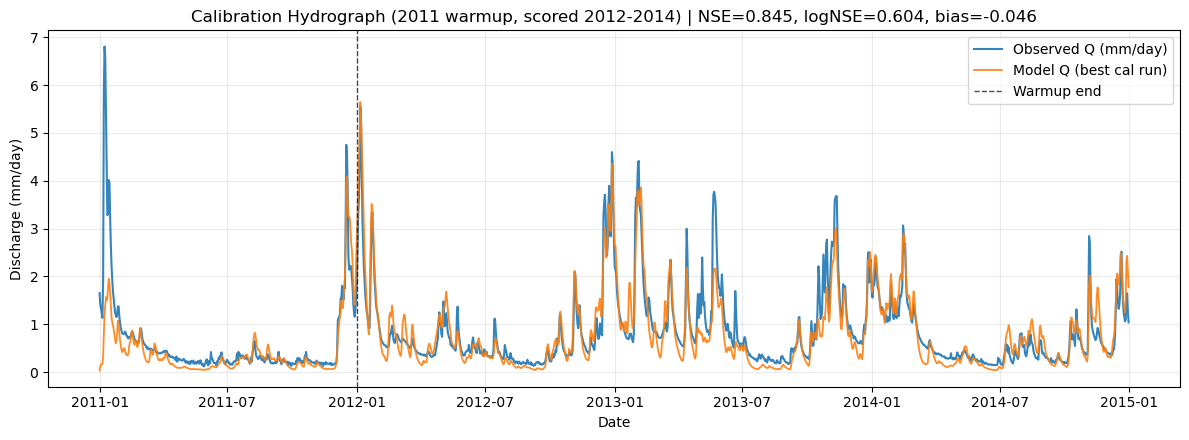

In [40]:
# Calibration hydrograph (forcing 2011-2014; metrics on 2012-2014 after warmup)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4.5))
plt.plot(daily_forcing.index, q_obs_daily, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(daily_forcing.index, sim_daily_best, label='Model Q (best cal run)', linewidth=1.3, alpha=0.9)
plt.axvline(pd.Timestamp('2012-01-01'), color='k', linestyle='--', linewidth=1.0, alpha=0.7, label='Warmup end')
plt.title(
    f'Calibration Hydrograph (2011 warmup, scored 2012-2014) | '
    f"NSE={best_daily['nse_cal']:.3f}, logNSE={best_daily['lognse_cal']:.3f}, bias={best_daily['rb_cal']:.3f}"
)
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# Validation run with best calibrated parameters using stitched daily CSV inputs
start_val = pd.Timestamp('2015-01-01')
end_val = pd.Timestamp('2017-12-31')

# Load stitched daily forcing CSVs and clip to validation window
precip_daily_all = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
evap_daily_all = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')
temp_daily_all = pd.read_csv(base_path / 'ERA5_daily_temp_1980-2025.csv')

for frame in (precip_daily_all, evap_daily_all, temp_daily_all):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')

precip_daily_all = precip_daily_all.set_index('time')
evap_daily_all = evap_daily_all.set_index('time')
temp_daily_all = temp_daily_all.set_index('time')

precip_daily_all['total_precipitation_daily'] = pd.to_numeric(precip_daily_all['total_precipitation_daily'], errors='coerce').replace(-9999, np.nan)
evap_daily_all['total_evaporation_daily'] = pd.to_numeric(evap_daily_all['total_evaporation_daily'], errors='coerce').replace(-9999, np.nan)
temp_daily_all['temperature_2m'] = pd.to_numeric(temp_daily_all['temperature_2m'], errors='coerce').replace(-9999, np.nan)

daily_forcing_val = pd.DataFrame(index=pd.date_range(start_val, end_val, freq='D'))
daily_forcing_val['precip_m_day'] = precip_daily_all['total_precipitation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['evap_m_day'] = evap_daily_all['total_evaporation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['temp_K'] = temp_daily_all['temperature_2m'].reindex(daily_forcing_val.index)

daily_forcing_val['precip_m_day'] = daily_forcing_val['precip_m_day'].interpolate(limit_direction='both')
daily_forcing_val['evap_m_day'] = daily_forcing_val['evap_m_day'].interpolate(limit_direction='both')
daily_forcing_val['temp_K'] = daily_forcing_val['temp_K'].interpolate(limit_direction='both')

daily_forcing_val['pr_mm_day'] = daily_forcing_val['precip_m_day'] * 1000.0
daily_forcing_val['pet_mm_day'] = (-daily_forcing_val['evap_m_day']).clip(lower=0) * 1000.0
daily_forcing_val['temp_C'] = daily_forcing_val['temp_K'] - 273.15
daily_forcing_val['delT_C'] = daily_forcing_val['temp_C'] - daily_forcing_val['temp_C'].mean()

q_obs_val = (
    grdc['q_m3s']
    .loc[start_val:end_val]
    .reindex(daily_forcing_val.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

if pd.infer_freq(daily_forcing_val.index) != 'D':
    raise ValueError('Validation forcing index is not daily.')

pr_da_val = xr.DataArray(daily_forcing_val['pr_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='pr')
pet_da_val = xr.DataArray(daily_forcing_val['pet_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='evspsblpot')
tas_da_val = xr.DataArray(daily_forcing_val['delT_C'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='tas')

cfg_val = {
    'precipitation_file': pr_da_val,
    'potential_evaporation_file': pet_da_val,
    'temperature_file': tas_da_val,
    'T_baseline': 0.0,
    'initial_storage': '0.0,100.0,0.0,5.0',
}

m_val = HBV_Bmi()
m_val.initialize(cfg_val)
m_val.set_pars(best_daily['params'])

sim_val = []
while m_val.current_timestep < m_val.end_timestep:
    m_val.update()
    out = np.array([0.0])
    m_val.get_value('Q', out)
    sim_val.append(out[0])
sim_val = np.asarray(sim_val, dtype=float)

nse_val = nse(q_obs_val, sim_val)
lognse_val = log_nse(q_obs_val, sim_val)
rb_val = rel_bias(q_obs_val, sim_val)

summary_val = pd.DataFrame({
    'metric': ['NSE_val_2015_2016', 'logNSE_val_2015_2016', 'rel_bias_val_2015_2016'],
    'value': [nse_val, lognse_val, rb_val],
})

print('Validation period:', daily_forcing_val.index.min(), 'to', daily_forcing_val.index.max(), '| n =', len(daily_forcing_val))
print('Input frequency (P/PET/T/Qobs): daily')
summary_val

NameError: name 'best_daily' is not defined

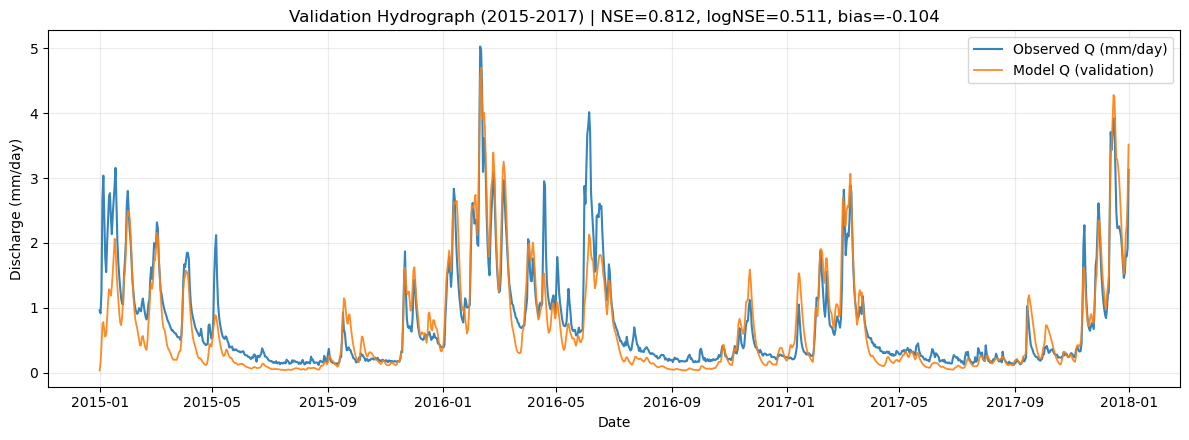

In [ ]:
# Validation hydrograph
plt.figure(figsize=(12, 4.5))
plt.plot(daily_forcing_val.index, q_obs_val, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(daily_forcing_val.index, sim_val, label='Model Q (validation)', linewidth=1.3, alpha=0.9)
plt.title(f'Validation Hydrograph (2015-2017) | NSE={nse_val:.3f}, logNSE={lognse_val:.3f}, bias={rb_val:.3f}')
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Using 5-year moving average
Concept:
- Keep rainfall, PET, and discharge daily.
- Replace `delT_C` with `delT_slow_C` using a 5-year moving average of temperature.
- Calibrate and validate with the same period split to compare against the fast daily-temperature gamma setup.

Here we use a trailing moving average window of 5 years (1825 days) as a conceptual representation of slow soil response to sustained warming. During the first 5 years of the record, the window is only partially filled, so the average is computed from available history only (shorter effective window). This makes the early-period `delT_slow_C` less smoothed than later years and can introduce mild spin-up edge effects.

In [8]:
# Build slow temperature anomaly for calibration period (5-year moving average)
if 'daily_forcing' not in globals():
    raise RuntimeError('Run the daily setup cell first so daily_forcing exists.')

window_days = 365 * 5  # 5-year trailing window
daily_forcing_slow = daily_forcing.copy()
daily_forcing_slow['temp_slow_C'] = daily_forcing_slow['temp_C'].rolling(
    window=window_days,
    min_periods=1
).mean()
daily_forcing_slow['delT_slow_C'] = daily_forcing_slow['temp_slow_C'] - daily_forcing_slow['temp_slow_C'].mean()

tas_da_mc_slow = xr.DataArray(
    daily_forcing_slow['delT_slow_C'].to_numpy(dtype=float),
    coords={'time': daily_forcing_slow.index},
    dims=('time',),
    name='tas',
)

print('Slow-dynamics gamma setup ready (5-year moving average).')
print('window_days =', window_days)
print('First 5 years use a shorter effective window because full history is not yet available.')
print('delT_fast range:', float(daily_forcing['delT_C'].min()), 'to', float(daily_forcing['delT_C'].max()))
print('delT_slow range:', float(daily_forcing_slow['delT_slow_C'].min()), 'to', float(daily_forcing_slow['delT_slow_C'].max()))

Slow-dynamics gamma setup ready (5-year moving average).
window_days = 1825
First 5 years use a shorter effective window because full history is not yet available.
delT_fast range: -23.862696340454832 to 19.417905221559167
delT_slow range: -11.645391773752504 to 0.880984336052455


In [31]:
from tqdm.notebook import tqdm  # Add this import
# MC calibration using slow-dynamics gamma (same periods and bounds)
if 'cal_mask' not in globals() or 'q_obs_daily' not in globals() or 'pr_da_mc' not in globals() or 'pet_da_mc' not in globals():
    raise RuntimeError('Run the daily setup cell first (it defines forcing and calibration masks).')

if 'nse' not in globals() or 'log_nse' not in globals() or 'rel_bias' not in globals():
    raise RuntimeError('Run the MC metric-definition cell first (nse/log_nse/rel_bias).')

# Reuse current bounds if present; otherwise define defaults
if 'ParMinn_mc' not in globals() or 'ParMaxn_mc' not in globals():
    ParMinn_mc = np.array([0.0, 0.1, 50.0, 0.8, 0.001, 0.5, 0.01, 0.001, -0.03])
    ParMaxn_mc = np.array([4.0, 1.2, 600.0, 4.0, 0.15, 6.0, 0.50, 0.05, 0.03])

N_mc_slow = 1000
results_mc_slow = []
obs_cal = q_obs_daily[cal_mask]

# Add progress bar to the loop
for _ in tqdm(range(N_mc_slow), desc="Monte Carlo Calibration", unit="run"):
    p = np.random.uniform(ParMinn_mc, ParMaxn_mc)
    cfg_slow = {
        'precipitation_file': pr_da_mc,
        'potential_evaporation_file': pet_da_mc,
        'temperature_file': tas_da_mc_slow,
        'T_baseline': 0.0,
        'initial_storage': '0.0,100.0,0.0,5.0',
    }

    m_slow = HBV_Bmi()
    m_slow.initialize(cfg_slow)
    m_slow.set_pars(p)

    sim = []
    while m_slow.current_timestep < m_slow.end_timestep:
        m_slow.update()
        out = np.array([0.0])
        m_slow.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    sim_cal = sim[cal_mask]
    nse_cal = nse(obs_cal, sim_cal)
    lognse_cal = log_nse(obs_cal, sim_cal)
    rb_cal = rel_bias(obs_cal, sim_cal)

    if np.isfinite(nse_cal) and np.isfinite(lognse_cal):
        results_mc_slow.append({
            'params': p,
            'sim_mm_day': sim,
            'nse_cal': nse_cal,
            'lognse_cal': lognse_cal,
            'rb_cal': rb_cal,
        })

if not results_mc_slow:
    raise RuntimeError('No valid slow-gamma MC runs found.')

best_daily_slow = max(results_mc_slow, key=lambda d: d['nse_cal'])
sim_daily_best_slow = best_daily_slow['sim_mm_day']

summary_daily_slow = pd.DataFrame({
    'metric': ['NSE_cal_2012_2014_slowGamma', 'logNSE_cal_2012_2014_slowGamma', 'rel_bias_cal_2012_2014_slowGamma'],
    'value': [best_daily_slow['nse_cal'], best_daily_slow['lognse_cal'], best_daily_slow['rb_cal']],
})

print('Valid slow-gamma runs:', len(results_mc_slow), '/', N_mc_slow)
print('Best slow-gamma parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):')
print(best_daily_slow['params'])
summary_daily_slow

Monte Carlo Calibration:   0%|          | 0/1000 [00:00<?, ?run/s]

Valid slow-gamma runs: 1000 / 1000
Best slow-gamma parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):
[2.81465763e+00 4.87180419e-01 3.01718767e+02 3.46980507e+00
 1.31329391e-01 4.11024485e+00 3.14562905e-01 4.39521527e-02
 1.47089227e-02]


,metric,value
0,NSE_cal_2012_2014_slowGamma,0.848650
1,logNSE_cal_2012_2014_slowGamma,0.423133
2,rel_bias_cal_2012_2014_slowGamma,-0.132471


In [32]:
import pandas as pd

# Extract only the scalar values (not the full sim_mm_day array)
results_summary = []
for result in results_mc_slow:
    results_summary.append({
        'nse_cal': result['nse_cal'],
        'lognse_cal': result['lognse_cal'],
        'rb_cal': result['rb_cal'],
        'Imax': result['params'][0],
        'Ce': result['params'][1],
        'Sumax0': result['params'][2],
        'beta': result['params'][3],
        'Pmax': result['params'][4],
        'Tlag': result['params'][5],
        'Kf': result['params'][6],
        'Ks': result['params'][7],
        'Gamma': result['params'][8]
    })

# Convert to DataFrame and save
df_results = pd.DataFrame(results_summary)
df_results.to_csv('results_mc_slow.csv', index=False)

print(f"Saved {len(df_results)} runs to results_mc_slow.csv")
print(f"Columns: {list(df_results.columns)}")

Saved 1000 runs to results_mc_slow.csv
Columns: ['nse_cal', 'lognse_cal', 'rb_cal', 'Imax', 'Ce', 'Sumax0', 'beta', 'Pmax', 'Tlag', 'Kf', 'Ks', 'Gamma']


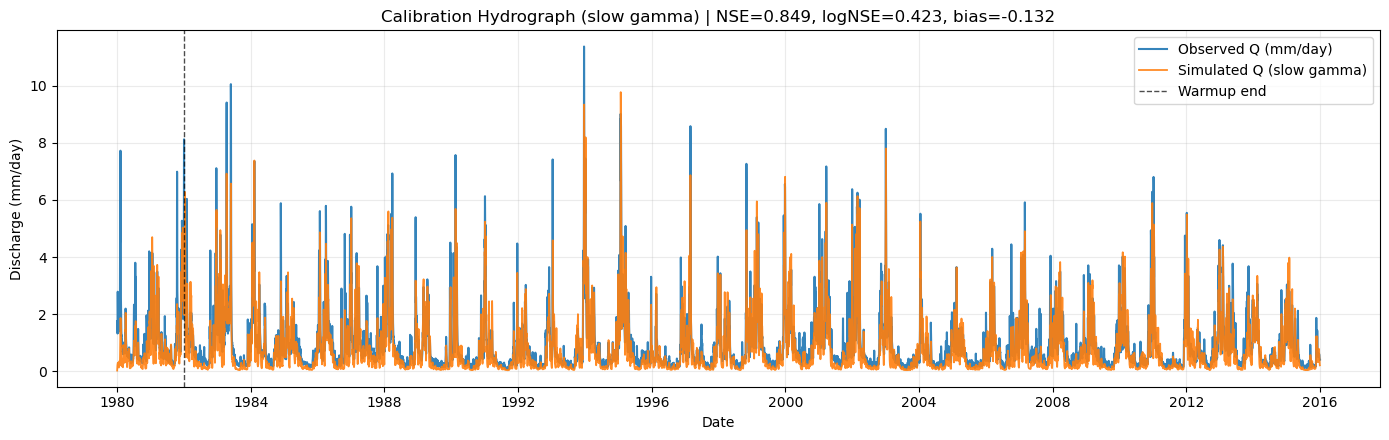

In [33]:
# Plot observed vs simulated calibration values for the slow-dynamics gamma run
import matplotlib.pyplot as plt

if 'daily_forcing' not in globals() or 'q_obs_daily' not in globals() or 'sim_daily_best_slow' not in globals():
    raise RuntimeError('Run the slow-gamma calibration setup cell first so daily_forcing, q_obs_daily, and sim_daily_best_slow exist.')

plt.figure(figsize=(14, 4.5))
plt.plot(daily_forcing.index, q_obs_daily, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(daily_forcing.index, sim_daily_best_slow, label='Simulated Q (slow gamma)', linewidth=1.3, alpha=0.9)
plt.axvline(pd.Timestamp('1982-01-01'), color='k', linestyle='--', linewidth=1.0, alpha=0.7, label='Warmup end')
plt.title(
    f"Calibration Hydrograph (slow gamma) | NSE={best_daily_slow['nse_cal']:.3f}, "
    f"logNSE={best_daily_slow['lognse_cal']:.3f}, bias={best_daily_slow['rb_cal']:.3f}"
)
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Validation with slow-dynamics gamma (same validation period)
start_val = pd.Timestamp('2016-01-01')
end_val = pd.Timestamp('2025-12-31')

daily_forcing_val = pd.DataFrame(index=pd.date_range(start_val, end_val, freq='D'))
daily_forcing_val['precip_m_day'] = precip_daily_all['total_precipitation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['evap_m_day'] = evap_daily_all['total_evaporation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['temp_K'] = temp_daily_all['temperature_2m'].reindex(daily_forcing_val.index)

daily_forcing_val['precip_m_day'] = daily_forcing_val['precip_m_day'].interpolate(limit_direction='both')
daily_forcing_val['evap_m_day'] = daily_forcing_val['evap_m_day'].interpolate(limit_direction='both')
daily_forcing_val['temp_K'] = daily_forcing_val['temp_K'].interpolate(limit_direction='both')

daily_forcing_val['pr_mm_day'] = daily_forcing_val['precip_m_day'] * 1000.0
daily_forcing_val['pet_mm_day'] = (-daily_forcing_val['evap_m_day']).clip(lower=0) * 1000.0
daily_forcing_val['temp_C'] = daily_forcing_val['temp_K'] - 273.15
daily_forcing_val['delT_C'] = daily_forcing_val['temp_C'] - daily_forcing_val['temp_C'].mean()

# Build slow temperature over a longer continuous index to avoid edge effects at validation start
slow_full_index = pd.date_range(start=daily_forcing.index.min(), end=daily_forcing_val.index.max(), freq='D')
temp_full = temp_daily.reindex(slow_full_index).interpolate(limit_direction='both')
window_days = 365 * 5
temp_slow_full = temp_full.rolling(window=window_days, min_periods=1).mean()
temp_slow_val = temp_slow_full.reindex(daily_forcing_val.index)

daily_forcing_val_slow = daily_forcing_val.copy()
daily_forcing_val_slow['temp_slow_C'] = temp_slow_val.to_numpy()
daily_forcing_val_slow['delT_slow_C'] = daily_forcing_val_slow['temp_slow_C'] - daily_forcing_val_slow['temp_slow_C'].mean()

tas_da_val_slow = xr.DataArray(
    daily_forcing_val_slow['delT_slow_C'].to_numpy(dtype=float),
    coords={'time': daily_forcing_val_slow.index},
    dims=('time',),
    name='tas',
)

cfg_val_slow = {
    'precipitation_file': pr_da_val,
    'potential_evaporation_file': pet_da_val,
    'temperature_file': tas_da_val_slow,
    'T_baseline': 0.0,
    'initial_storage': '0.0,100.0,0.0,5.0',
}

m_val_slow = HBV_Bmi()
m_val_slow.initialize(cfg_val_slow)
m_val_slow.set_pars(best_daily_slow['params'])

sim_val_slow = []
while m_val_slow.current_timestep < m_val_slow.end_timestep:
    m_val_slow.update()
    out = np.array([0.0])
    m_val_slow.get_value('Q', out)
    sim_val_slow.append(out[0])
sim_val_slow = np.asarray(sim_val_slow, dtype=float)

nse_val_slow = nse(q_obs_val, sim_val_slow)
lognse_val_slow = log_nse(q_obs_val, sim_val_slow)
rb_val_slow = rel_bias(q_obs_val, sim_val_slow)

summary_val_slow = pd.DataFrame({
    'metric': ['NSE_val_slowGamma', 'logNSE_val_slowGamma', 'rel_bias_val_slowGamma'],
    'value': [nse_val_slow, lognse_val_slow, rb_val_slow],
})

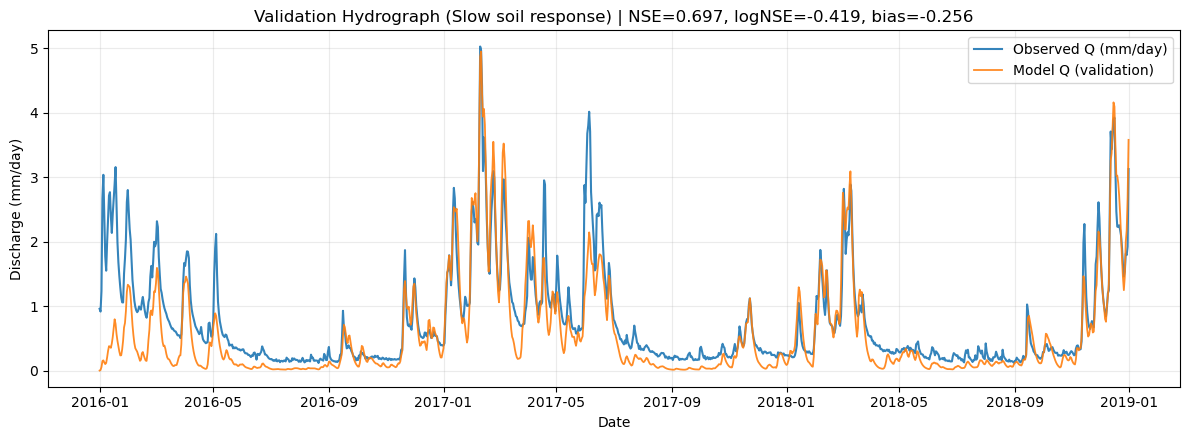

In [29]:
# Validation hydrograph
n_plot = min(len(daily_forcing_val.index), len(q_obs_val), len(sim_val_slow))
plot_index = daily_forcing_val.index[:n_plot]
plot_obs = q_obs_val[:n_plot]
plot_sim = sim_val_slow[:n_plot]

plt.figure(figsize=(12, 4.5))
plt.plot(plot_index, plot_obs, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(plot_index, plot_sim, label='Model Q (validation)', linewidth=1.3, alpha=0.9)
plt.title(f'Validation Hydrograph (Slow soil response) | NSE={nse_val_slow:.3f}, logNSE={lognse_val_slow:.3f}, bias={rb_val_slow:.3f}')
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# Sort results by NSE in descending order and get top 5
top_5 = sorted(results_mc_slow, key=lambda x: x['nse_cal'], reverse=True)[:5]

for i, result in enumerate(top_5, 1):
    print(f"\n🏆 RANK {i}:")
    print(f"   NSE: {result['nse_cal']:.6f}")
    print(f"   LogNSE: {result['lognse_cal']:.6f}")
    print(f"   Relative Bias: {result['rb_cal']:.6f}")
    print(f"   Parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):")
    print(f"   {result['params']}")
    print("-" * 80)


🏆 RANK 1:
   NSE: 0.848650
   LogNSE: 0.423133
   Relative Bias: -0.132471
   Parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):
   [2.81465763e+00 4.87180419e-01 3.01718767e+02 3.46980507e+00
 1.31329391e-01 4.11024485e+00 3.14562905e-01 4.39521527e-02
 1.47089227e-02]
--------------------------------------------------------------------------------

🏆 RANK 2:
   NSE: 0.848459
   LogNSE: 0.642935
   Relative Bias: -0.073657
   Parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):
   [ 1.14681103e+00  3.03073288e-01  2.11885638e+02  1.56454819e+00
  1.42650518e-01  3.63681687e+00  2.24940021e-01  1.92416074e-02
 -1.47129485e-02]
--------------------------------------------------------------------------------

🏆 RANK 3:
   NSE: 0.842785
   LogNSE: 0.746244
   Relative Bias: -0.025673
   Parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):
   [4.46846530e-01 5.98158315e-01 4.48927753e+02 3.51719101e+00
 1.41681387e-01 3.49393413e+00 2.71377808e-01 1.8942

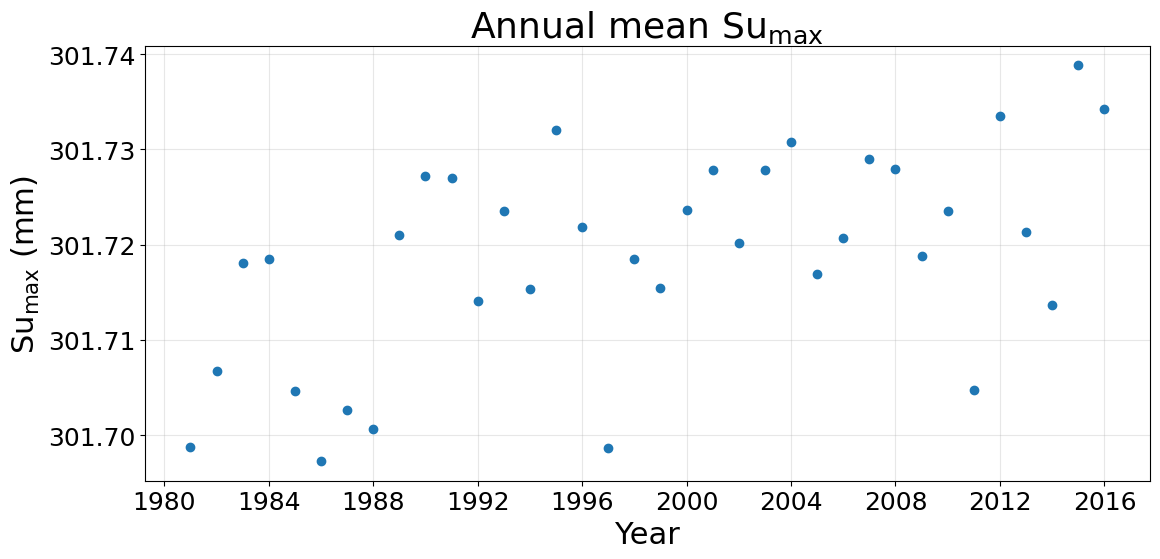

In [63]:
# plot Su_max against delta temperature 
best_Sumax0 = best_daily_slow['params'][2]
best_gamma = best_daily_slow['params'][8]

# best_Sumax0 = 278.586
# best_gamma = -0.019167

tests = daily_forcing.copy()
tests['ts_Sumax'] = best_Sumax0 + best_gamma * daily_forcing['delT_C']

# Calculate annual means
annual_means = tests['ts_Sumax'].resample("YE").mean()

# Plot annual means against time (not against daily index)
plt.figure(figsize=(12, 6))
plt.plot(annual_means.index, annual_means.values, 'o', linewidth=2, markersize=6)
plt.xlabel('Year')
plt.ylabel(r'$\mathrm{Su_{max}}$ (mm)')
plt.title(r'$\mathrm{Annual \ mean \ Su_{max}}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

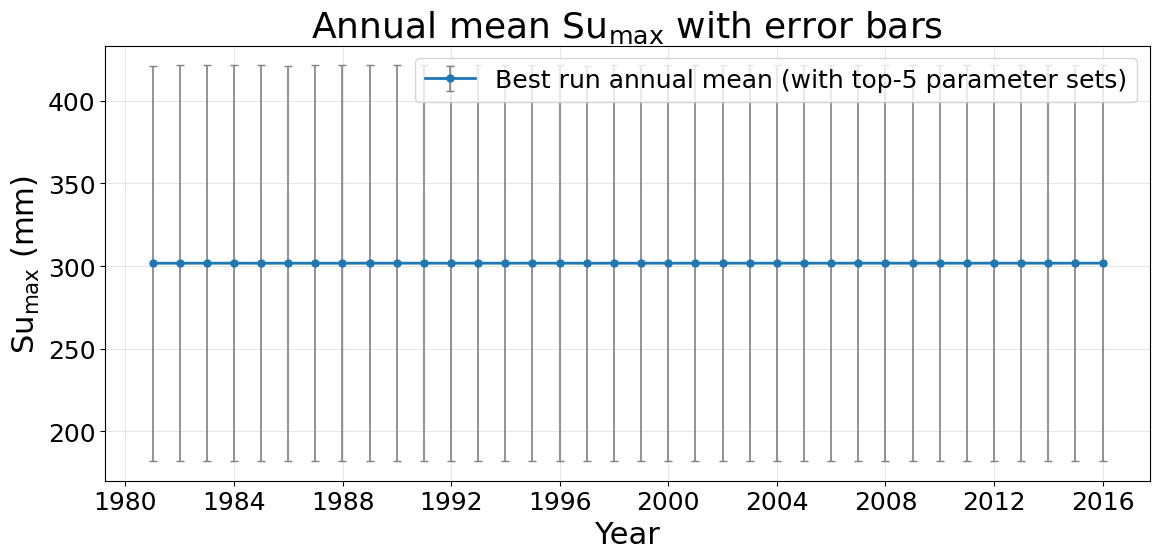

Best run NSE: 0.848650
Top 5 NSE values used:
1. NSE = 0.848650
2. NSE = 0.848459
3. NSE = 0.842785


,year,best_run_mean_Su_max_mm,top5_mean_Su_max_mm,top5_std_Su_max_mm
0,1980,301.698804,320.843541,119.664459
1,1981,301.706786,320.843746,119.667784
2,1982,301.718035,320.844034,119.672472
3,1983,301.718515,320.844046,119.672672
4,1984,301.704637,320.843691,119.666889
5,1985,301.697299,320.843503,119.663832
6,1986,301.702658,320.843640,119.666064
7,1987,301.700600,320.843587,119.665207
8,1988,301.721053,320.844111,119.673730
9,1989,301.727203,320.844269,119.676292


In [62]:
# Annual mean Su_max with error bars from top 5 NSE parameter sets
# Center line = best run (same as previous annual plot)
# Error bars = spread (std) across top 5 NSE runs
if 'results_mc_slow' not in globals() or len(results_mc_slow) < 5:
    raise RuntimeError('Run the slow-gamma MC calibration cell first (need at least 5 valid runs).')
if 'best_daily_slow' not in globals():
    raise RuntimeError('Run the slow-gamma MC calibration cell first so best_daily_slow exists.')
if 'daily_forcing' not in globals() or 'delT_C' not in daily_forcing.columns:
    raise RuntimeError("Run the daily forcing setup cell first so daily_forcing['delT_C'] exists.")

# Select top 5 calibrated parameter sets by NSE
top_5 = sorted(results_mc_slow, key=lambda x: x['nse_cal'], reverse=True)[:3]

# Build annual series for top 5
a1l_annual_means = []
for i, result in enumerate(top_5, start=1):
    params = result['params']
    Sumax0 = params[2]
    gamma = params[8]

    daily_su = Sumax0 + gamma * daily_forcing['delT_C']
    annual_means_temp = daily_su.resample('YE').mean()
    annual_means_temp.name = f'top{i}'
    a1l_annual_means.append(annual_means_temp)

df_annual = pd.concat(a1l_annual_means, axis=1).dropna(how='any')
std_su = df_annual.std(axis=1, ddof=1)
mean_top5 = df_annual.mean(axis=1)

# Best-run annual series (matches the previous annual Su_max plot)
best_Sumax0 = best_daily_slow['params'][2]
best_gamma = best_daily_slow['params'][8]
best_daily_su = best_Sumax0 + best_gamma * daily_forcing['delT_C']
mean_su = best_daily_su.resample('YE').mean().reindex(df_annual.index)

plt.figure(figsize=(12, 6))
plt.errorbar(
    mean_su.index,
    mean_su.values,
    yerr=std_su.values,
    fmt='o-',
    linewidth=2,
    markersize=5,
    capsize=3,
    ecolor='gray',
    elinewidth=1.2,
    label='Best run annual mean (with top-5 parameter sets)'
)
#plt.plot(mean_top5.index, mean_top5.values, '--', alpha=0.7, label='Top-5 mean (reference)')
plt.xlabel('Year')
plt.ylabel(r'$\mathrm{Su_{max}}$ (mm)')
plt.title(r'Annual mean $\mathrm{Su_{max}}$ with error bars')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('Best run NSE:', f"{best_daily_slow['nse_cal']:.6f}")
print('Top 5 NSE values used:')
for i, result in enumerate(top_5, start=1):
    print(f"{i}. NSE = {result['nse_cal']:.6f}")

pd.DataFrame({
    'year': mean_su.index.year,
    'best_run_mean_Su_max_mm': mean_su.values,
    'top5_mean_Su_max_mm': mean_top5.values,
    'top5_std_Su_max_mm': std_su.values,
})

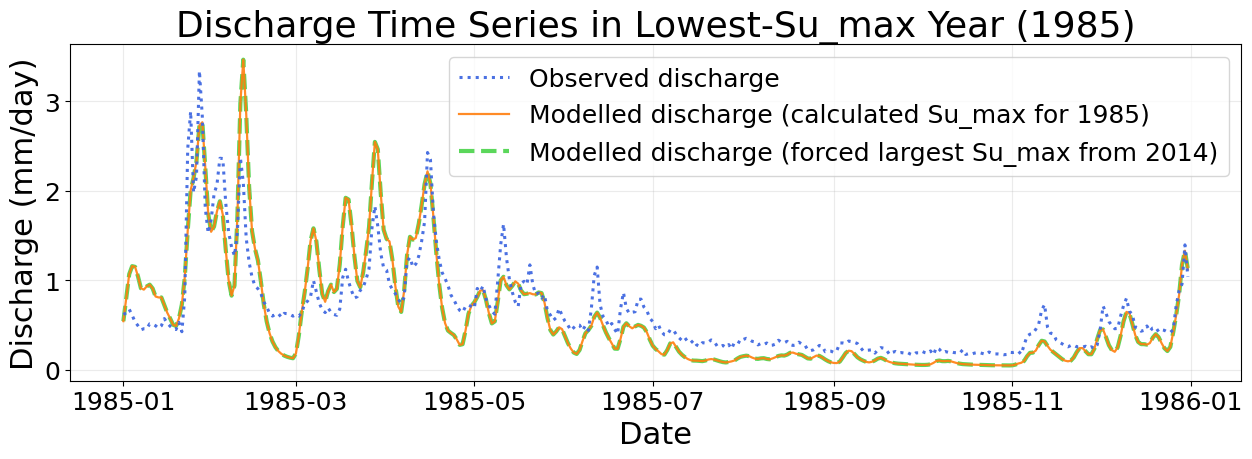

Lowest annual Su_max year: 1985 | Su_max = 301.697 mm
Max annual Su_max year: 2014 | Su_max = 301.739 mm
Forced tas anomaly used in 1985: 1.363800


In [43]:
# Discharge time series for the year with lowest annual Su_max
# Lines shown:
# 1) Observed discharge
# 2) Modelled discharge with calculated (best-run) Su_max
# 3) Modelled discharge with forced max-Su_max condition in that same year

if 'daily_forcing' not in globals():
    raise RuntimeError('Run daily forcing setup first so daily_forcing exists.')
if 'q_obs_daily' not in globals() or 'sim_daily_best_slow' not in globals():
    raise RuntimeError('Run the slow-gamma calibration cell first to create q_obs_daily and sim_daily_best_slow.')
if 'best_daily_slow' not in globals() or 'pr_da_mc' not in globals() or 'pet_da_mc' not in globals():
    raise RuntimeError('Run the calibration setup cell first so best parameters and forcing DataArrays exist.')

# Build annual Su_max from the best run (use the same signal as your annual Su_max plot)
best_Sumax0 = float(best_daily_slow['params'][2])
best_gamma = float(best_daily_slow['params'][8])
if abs(best_gamma) < 1e-12:
    raise RuntimeError('Gamma is too close to zero; cannot map a target Su_max back to temperature anomaly.')

if 'delT_C' in daily_forcing.columns:
    su_signal_for_year_pick = daily_forcing['delT_C']
else:
    raise RuntimeError("daily_forcing['delT_C'] is required.")

best_daily_su_local = best_Sumax0 + best_gamma * su_signal_for_year_pick
annual_su_local = best_daily_su_local.resample('YE').mean()

low_year = int(annual_su_local.idxmin().year)
max_year = int(annual_su_local.idxmax().year)
max_su_value = float(annual_su_local.max())

# Build observed and baseline simulated discharge series
full_index = daily_forcing.index
q_obs_series = pd.Series(np.asarray(q_obs_daily, dtype=float), index=full_index)
q_sim_best_series = pd.Series(np.asarray(sim_daily_best_slow, dtype=float), index=full_index)

# Create a counterfactual temperature-anomaly signal for model rerun:
# in the low-Su_max year, force Su_max to the max annual Su_max value
if 'daily_forcing_slow' in globals() and 'delT_slow_C' in daily_forcing_slow.columns:
    model_tas_signal = daily_forcing_slow['delT_slow_C'].reindex(full_index).copy()
else:
    model_tas_signal = daily_forcing['delT_C'].copy()

tas_forced_value = (max_su_value - best_Sumax0) / best_gamma
model_tas_counterfactual = model_tas_signal.copy()
model_tas_counterfactual.loc[model_tas_counterfactual.index.year == low_year] = tas_forced_value

tas_da_counter = xr.DataArray(
    model_tas_counterfactual.to_numpy(dtype=float),
    coords={'time': full_index},
    dims=('time',),
    name='tas',
)

cfg_counter = {
    'precipitation_file': pr_da_mc,
    'potential_evaporation_file': pet_da_mc,
    'temperature_file': tas_da_counter,
    'T_baseline': 0.0,
    'initial_storage': '0.0,100.0,0.0,5.0',
}

m_counter = HBV_Bmi()
m_counter.initialize(cfg_counter)
m_counter.set_pars(best_daily_slow['params'])

sim_counter = []
while m_counter.current_timestep < m_counter.end_timestep:
    m_counter.update()
    out = np.array([0.0])
    m_counter.get_value('Q', out)
    sim_counter.append(out[0])
sim_counter = np.asarray(sim_counter, dtype=float)
q_sim_counter_series = pd.Series(sim_counter, index=full_index)

# Slice the selected low-Su_max year
year_mask = full_index.year == low_year
plot_index = full_index[year_mask]
obs_year = q_obs_series.loc[plot_index]
sim_best_year = q_sim_best_series.loc[plot_index]
sim_counter_year = q_sim_counter_series.loc[plot_index]

plt.figure(figsize=(13, 5))
plt.plot(plot_index, obs_year.values,
         color='royalblue', linestyle=':', linewidth=2.2, alpha=0.95, zorder=4,
         label='Observed discharge')

plt.plot(plot_index, sim_best_year.values,
         color='tab:orange', linestyle='-', linewidth=1.6, alpha=0.9, zorder=2,
         label='Modelled discharge (calculated Su_max for 1985)')

plt.plot(plot_index, sim_counter_year.values,
         color='limegreen', linestyle='--', linewidth=3.0, alpha=0.8, zorder=1,
         label=f'Modelled discharge (forced largest Su_max from {max_year})')

plt.title(f'Discharge Time Series in Lowest-Su_max Year ({low_year})')
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Lowest annual Su_max year: {low_year} | Su_max = {annual_su_local.min():.3f} mm')
print(f'Max annual Su_max year: {max_year} | Su_max = {max_su_value:.3f} mm')
print(f'Forced tas anomaly used in {low_year}: {tas_forced_value:.6f}')

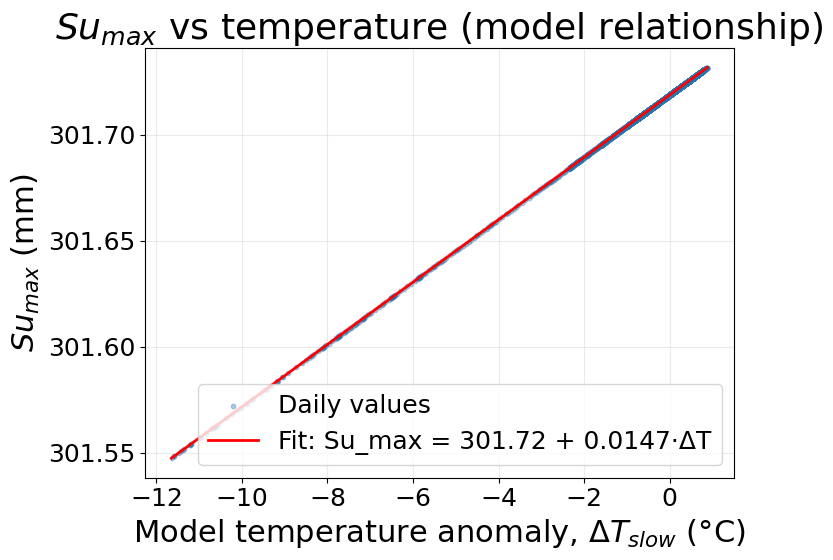

In [64]:
# Plot Su_max against temperature signal used by the model
import numpy as np
import matplotlib.pyplot as plt

if 'daily_forcing_slow' in globals() and 'best_daily_slow' in globals():
    # Slow-gamma setup
    temp_x = daily_forcing_slow['delT_slow_C'].to_numpy(dtype=float)  # model temperature input (anomaly)
    Sumax0 = float(best_daily_slow['params'][2])
    gamma = float(best_daily_slow['params'][8])
    x_label = r'Model temperature anomaly, $\Delta T_{slow}$ (°C)'
elif 'daily_forcing' in globals() and 'best_daily' in globals():
    # Fast-gamma setup
    temp_x = daily_forcing['delT_C'].to_numpy(dtype=float)
    Sumax0 = float(best_daily['params'][2])
    gamma = float(best_daily['params'][8])
    x_label = r'Model temperature anomaly, $\Delta T$ (°C)'
else:
    raise RuntimeError("Run calibration/setup first so daily_forcing(_slow) and best_daily(_slow) exist.")

su_max = Sumax0 + gamma * temp_x

# Optional linear fit (should match model relation)
coef = np.polyfit(temp_x, su_max, 1)
x_fit = np.linspace(np.nanmin(temp_x), np.nanmax(temp_x), 200)
y_fit = coef[0] * x_fit + coef[1]

plt.figure(figsize=(8, 6))
plt.scatter(temp_x, su_max, s=10, alpha=0.35, label='Daily values')
plt.plot(x_fit, y_fit, 'r-', lw=2, label=f'Fit: Su_max = {coef[1]:.2f} + {coef[0]:.4f}·ΔT')
plt.xlabel(x_label)
plt.ylabel(r'$Su_{max}$ (mm)')
plt.title(r'$Su_{max}$ vs temperature (model relationship)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()